# Resultados Fase 2 — Subempleo (AOI=03)

LightGBM sobre ocupados, ablación demografía vs laborales, SHAP y errores por jornada/sector/ocupación/CCAA.

Figuras en `reports/figures/fase2/` y `reports/figures/fase2/cierre/`.


## 1. Regenerar / cargar el cierre

Ejecuta la celda para (re)crear ablación, waterfalls y errores. Usa el modelo completo ya guardado en `models/fase2/`.


In [1]:
import importlib
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "modelado":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src.modeling.fase2_cierre as cierre
cierre = importlib.reload(cierre)
resumen = cierre.ejecutar_cierre_fase2()
resumen


 FASE 2 — ablación, SHAP local y errores
  -> Split temporal: train hasta 2024T4 (836,021 filas), test desde 2025T1 (243,918 filas).

--- Baseline prevalencia ---
  PR-AUC=0.0690  (prevalencia=0.0779)

--- Cargando modelo laboral completo ---
  Completo @0.50 PR-AUC=0.4794 | @0.825 F1=0.5158

 ABLACIÓN: solo demografía (14 features)
  Features: ANIO_REF, TRIMESTRE_REF, CCAA, PROV, SEXO, TRAMO_EDAD, NIVEL_EDUC, ESTADO_CIVIL, NACIONALIDAD, ROL_HOGAR, ESTUDIANDO_AHORA, TAM_HOGAR, CARGA_FAMILIAR, VULNERABILIDAD_JOVEN
  Buscando hiperparámetros (LightGBM demográfico)...
  Búsqueda en 51.3s. PR-AUC CV=0.1759
  Test @0.50 -> PR-AUC=0.1632  ROC-AUC=0.7139  F1=0.2139
  Umbral F1=0.625 -> F1=0.2354
  -> C:\Users\Borja\Desktop\TFG-GCF-borjarog\reports\figures\fase2\cierre\ablacion_demografia_vs_laboral.png

 ANÁLISIS DE ERRORES
  -> C:\Users\Borja\Desktop\TFG-GCF-borjarog\reports\figures\fase2\cierre\errores_por_jornada.png
  -> C:\Users\Borja\Desktop\TFG-GCF-borjarog\reports\figures\fase2\cierre

c:\Users\Borja\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Borja\Desktop\TFG-GCF-borjarog\src\modeling\interpretability.py:226: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


  -> shap_waterfall_tp_subempleo.png (idx=11962, proba=0.971)


c:\Users\Borja\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Borja\Desktop\TFG-GCF-borjarog\src\modeling\interpretability.py:226: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


  -> shap_waterfall_tn_no_subempleo.png (idx=241558, proba=0.003)


c:\Users\Borja\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Borja\Desktop\TFG-GCF-borjarog\src\modeling\interpretability.py:226: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


  -> shap_waterfall_fn_subempleo.png (idx=107356, proba=0.825)

Resumen: C:\Users\Borja\Desktop\TFG-GCF-borjarog\reports\fase2\cierre\resumen_cierre.md
Cierre Fase 2 terminado.


{'ablacion': {'baseline_prevalencia': {'pr_auc': 0.06896170024352447,
   'roc_auc': 0.5,
   'f1': 0.0},
  'solo_demografia': {'pr_auc': 0.1631642755779773,
   'roc_auc': 0.7138553622997013,
   'f1': 0.2139488409272582,
   'f1_umbral_optimo': 0.23539486203615603,
   'umbral': 0.625,
   'n_features': 14},
  'modelo_completo': {'pr_auc': 0.4794135983136068,
   'roc_auc': 0.8955164053897541,
   'f1': 0.42185682904768057,
   'f1_umbral_optimo': 0.5157542020212939,
   'umbral': 0.825,
   'n_features': 28}},
 'errores_resumen_keys': ['TIPO_JORNADA',
  'SECTOR_ACTIVIDAD',
  'OCUPACION',
  'CCAA_NOMBRE'],
 'waterfalls': ['shap_waterfall_tp_subempleo.png',
  'shap_waterfall_tn_no_subempleo.png',
  'shap_waterfall_fn_subempleo.png'],
 'umbral_modelo_completo': 0.825}

## 2. Resumen numérico


In [2]:
import json
from IPython.display import Markdown, display

with open(ROOT / "reports/fase2/cierre/cierre_prioridad1.json", encoding="utf-8") as f:
    datos = json.load(f)
with open(ROOT / "reports/fase2/comparacion_modelos.json", encoding="utf-8") as f:
    full = json.load(f)

ab = datos["ablacion"]
print("=== ABLACIÓN (PR-AUC test) ===")
print(f"Baseline:        {ab['baseline_prevalencia']['pr_auc']:.4f}")
print(f"Solo demografía: {ab['solo_demografia']['pr_auc']:.4f}")
print(f"Completo:        {ab['modelo_completo']['pr_auc']:.4f}")
print(f"Salto:           +{ab['modelo_completo']['pr_auc'] - ab['solo_demografia']['pr_auc']:.4f}")
print()
print("=== MODELO COMPLETO ===")
print(f"Ganador: {full['ganador']}")
print(f"Umbral F1: {full['umbral_optimo_f1_train']:.3f}")
print(f"F1 umbral optimo: {full['metricas_test_umbral_optimo']['f1']:.4f}")
print(f"ROC-AUC: {full['metricas_test_umbral_05']['roc_auc']:.4f}")
display(Markdown((ROOT / "reports/fase2/cierre/resumen_cierre.md").read_text(encoding="utf-8")))


=== ABLACIÓN (PR-AUC test) ===
Baseline:        0.0690
Solo demografía: 0.1632
Completo:        0.4794
Salto:           +0.3162

=== MODELO COMPLETO ===
Ganador: lightgbm
Umbral F1: 0.825
F1 umbral optimo: 0.5158
ROC-AUC: 0.8955


# Cierre Fase 2 — Prioridad 1

## Ablación
- Baseline PR-AUC: **0.0690**
- Solo demografía (LightGBM, 14 vars): **PR-AUC=0.1632**
- Modelo completo (+ laborales, 28 vars): **PR-AUC=0.4794**
- Salto demografía → completo: **+0.3162** PR-AUC

## Umbrales F1 (train)
- Completo: 0.825 → F1 test=0.5158
- Ablación: 0.625 → F1 test=0.2354

## Figuras
- `ablacion_demografia_vs_laboral.png`
- `errores_por_jornada.png` / sector / ocupación / CCAA
- Waterfalls SHAP locales

## Lectura
Las variables laborales aportan la mayor parte del poder predictivo del subempleo;
la demografía sola apenas supera el baseline en PR-AUC relativo al modelo completo.


## 3. Galería de figuras


### `reports\figures\fase2`

#### `curva_pr.png`

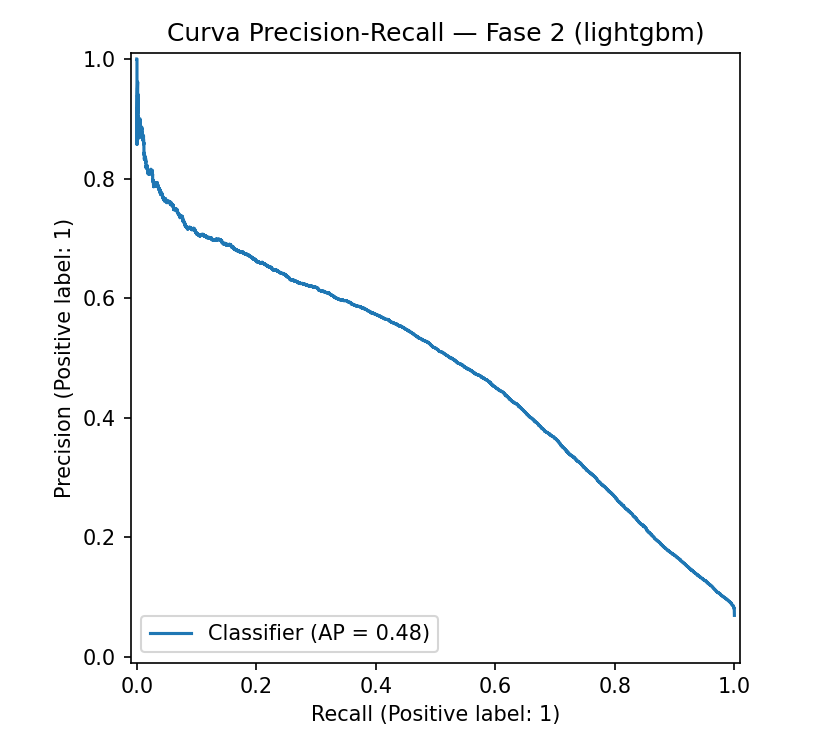

#### `matriz_confusion_umbral_05.png`

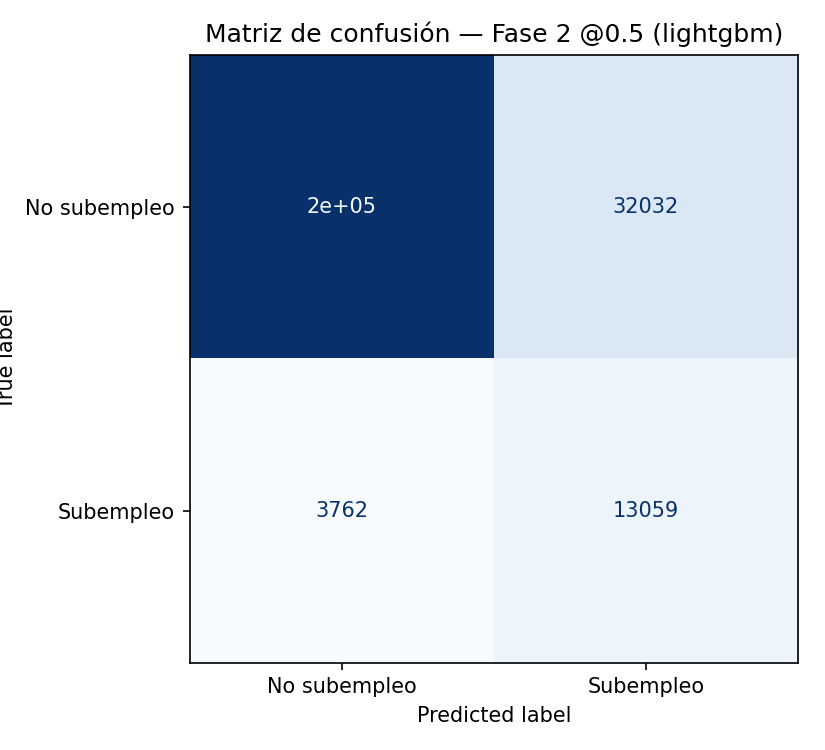

#### `matriz_confusion_umbral_optimo.png`

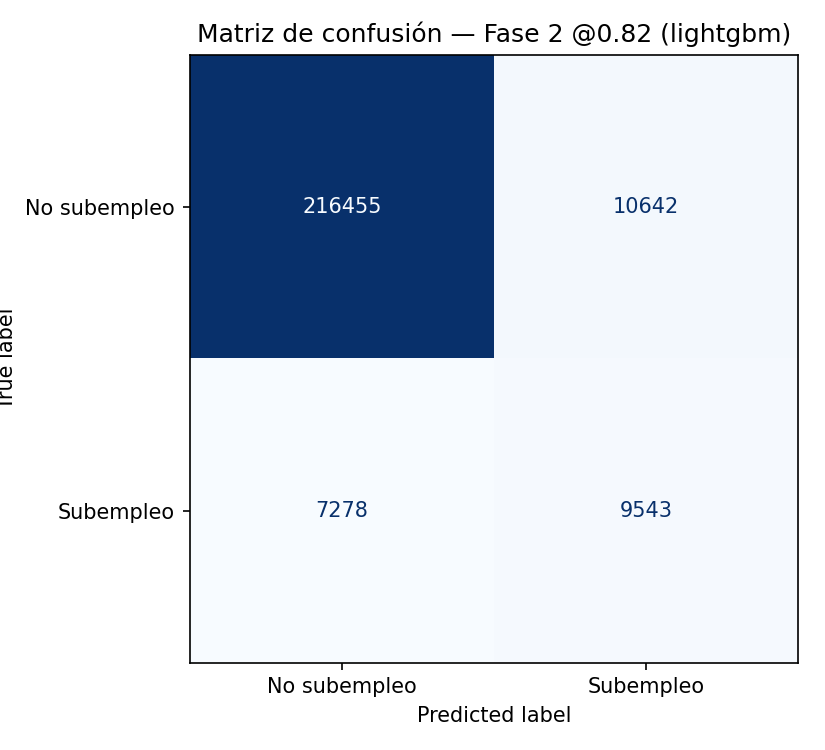

#### `shap_importancia_barras.png`

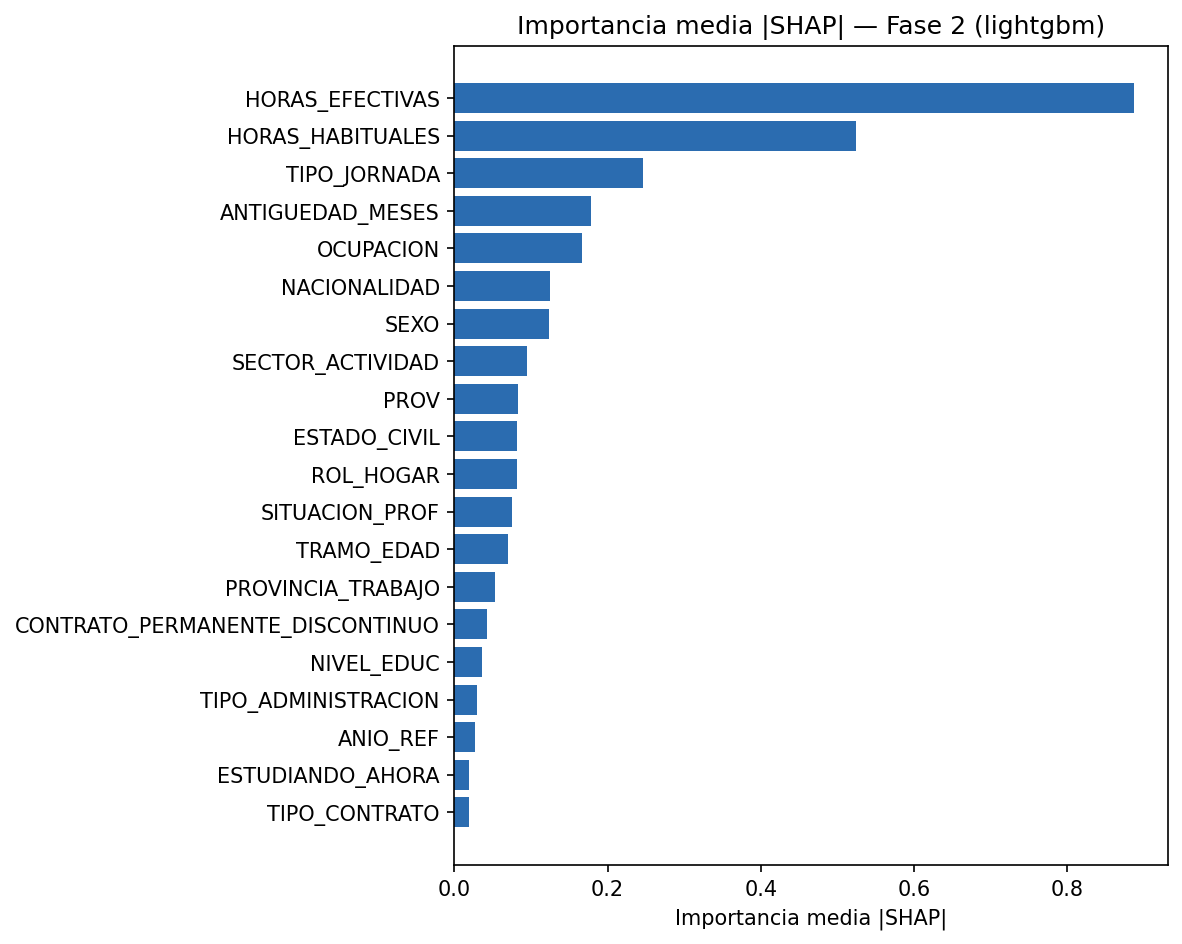

#### `shap_summary.png`

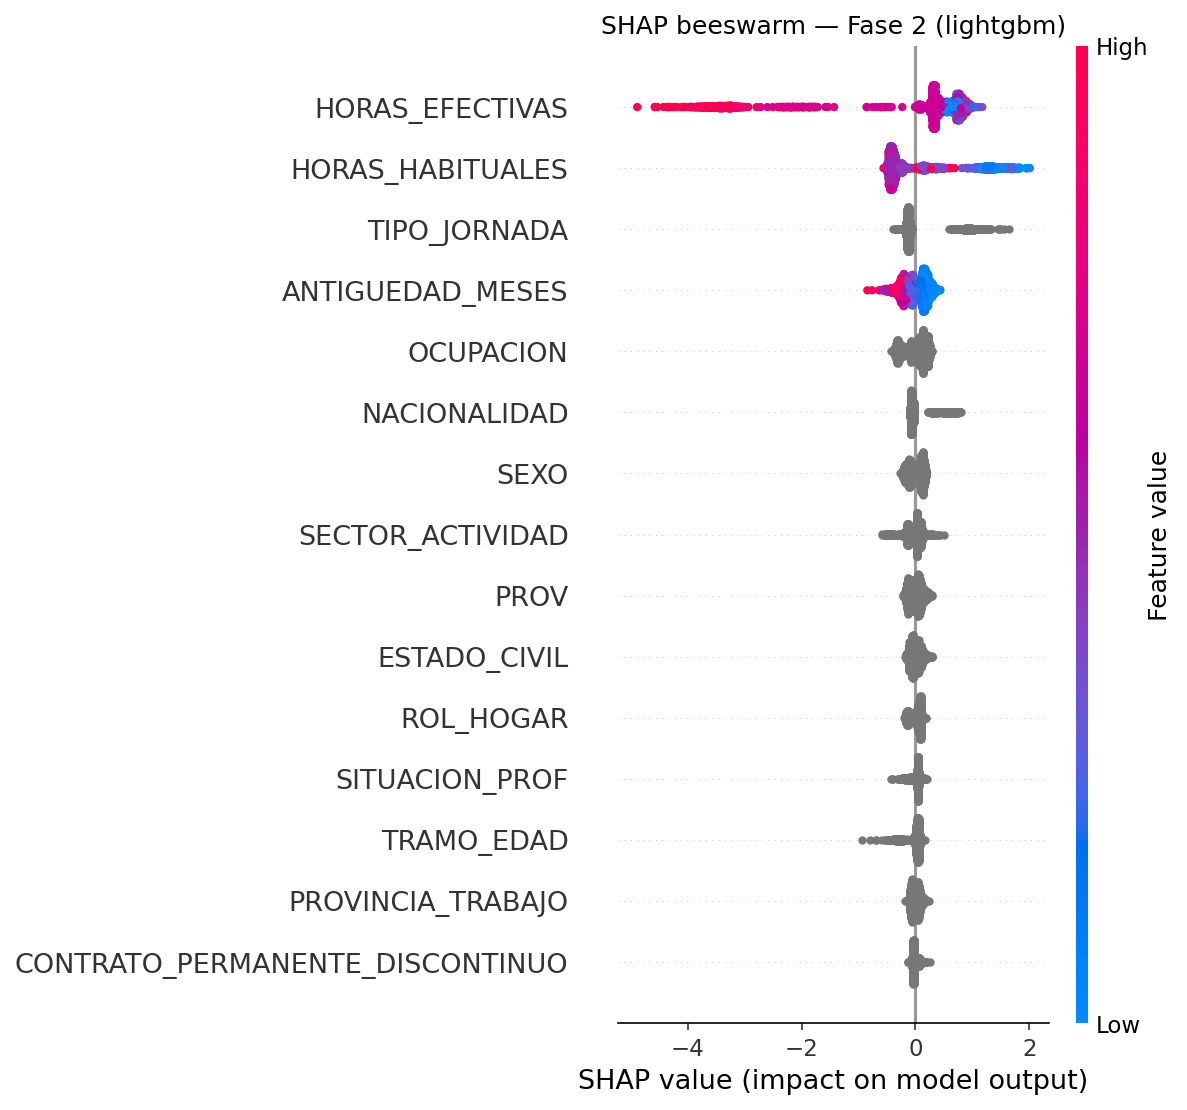

### `reports\figures\fase2\cierre`

#### `ablacion_demografia_vs_laboral.png`

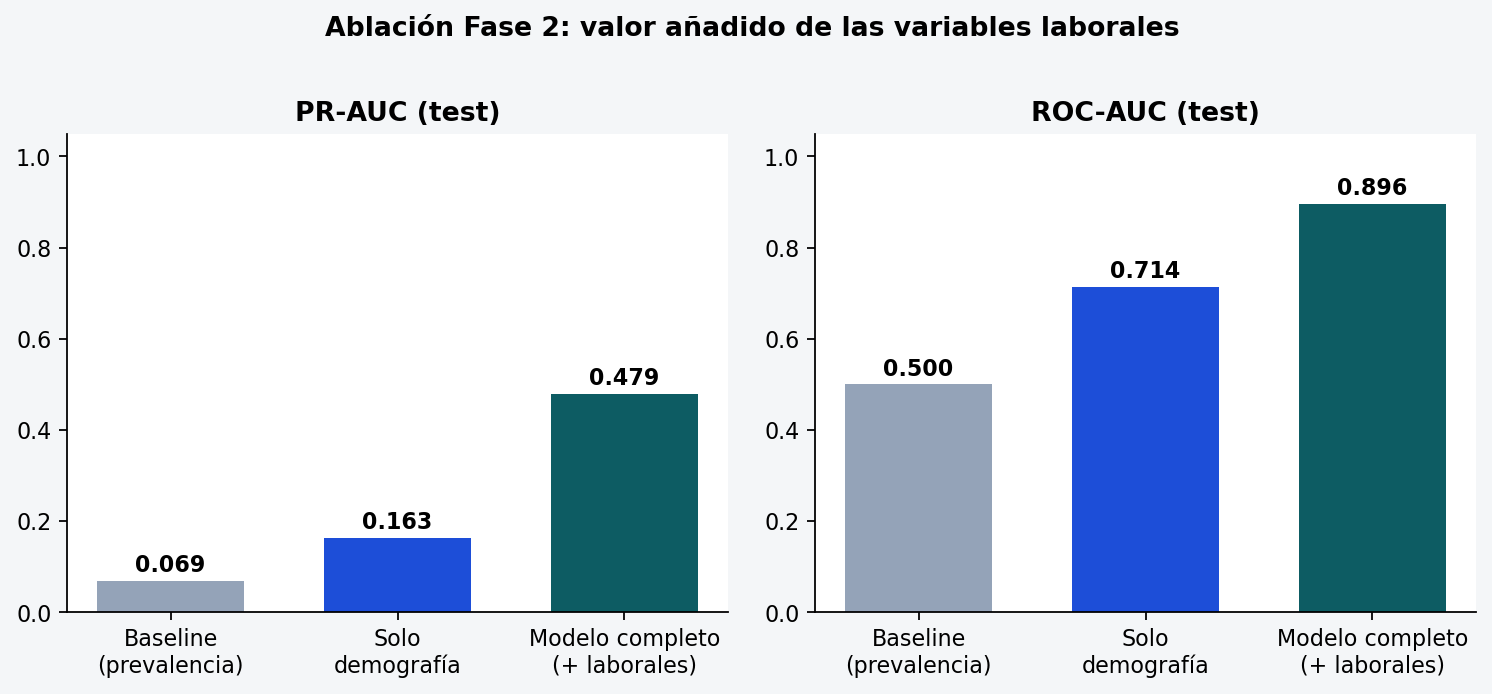

#### `errores_por_ccaa.png`

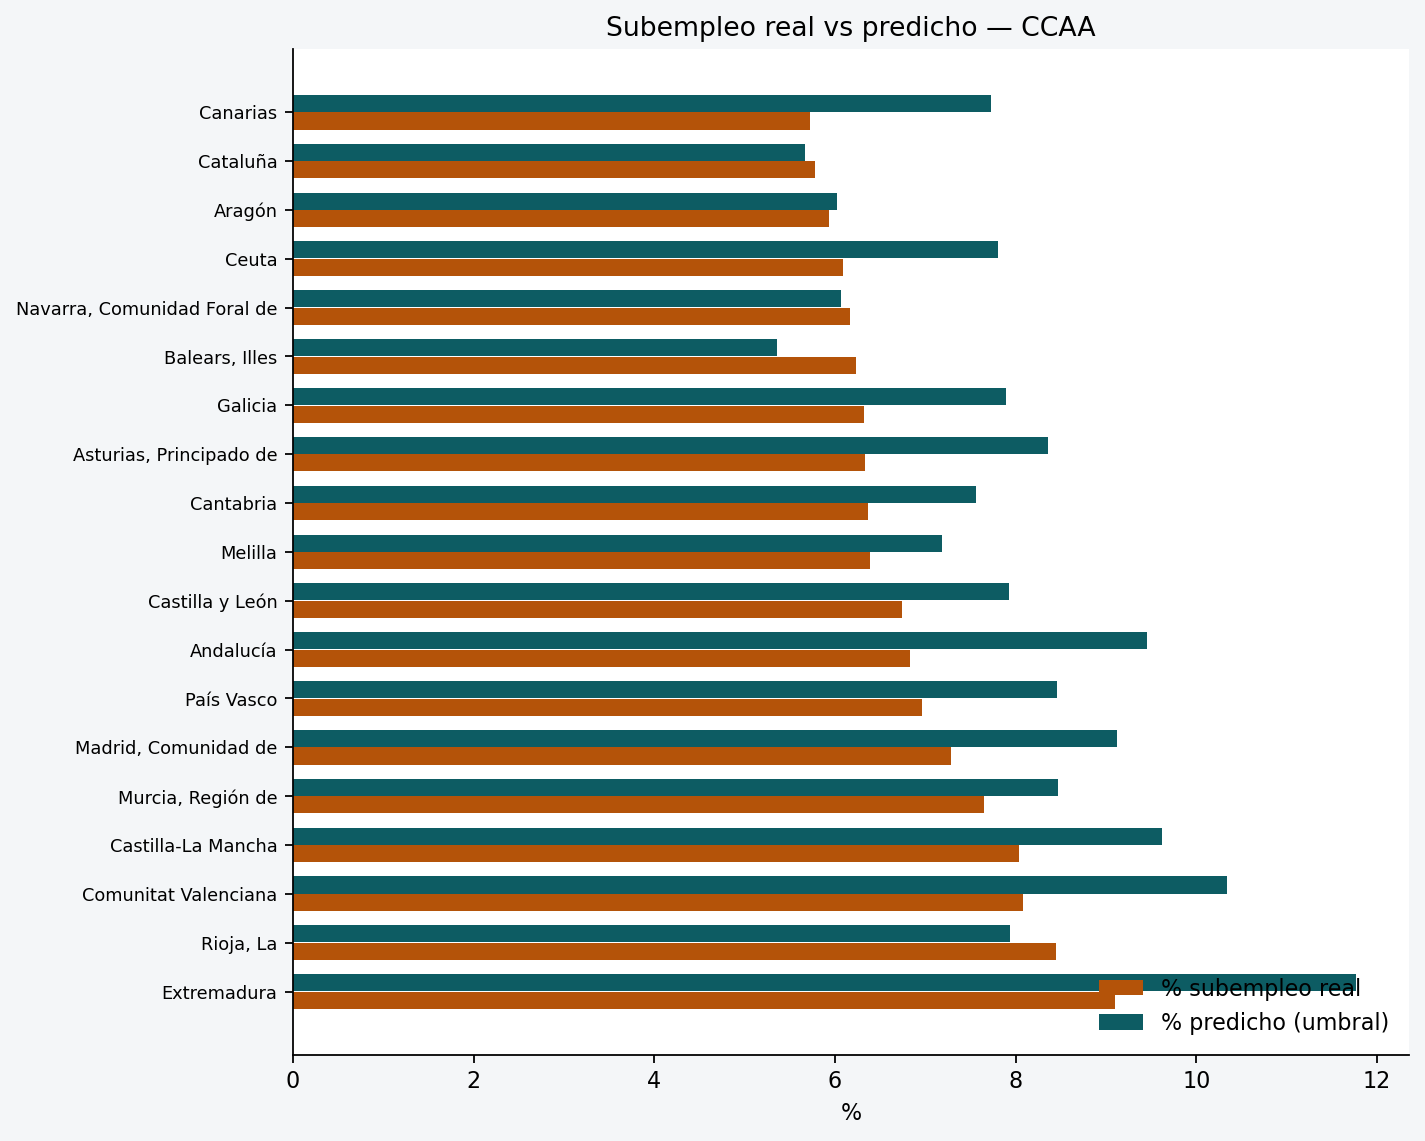

#### `errores_por_jornada.png`

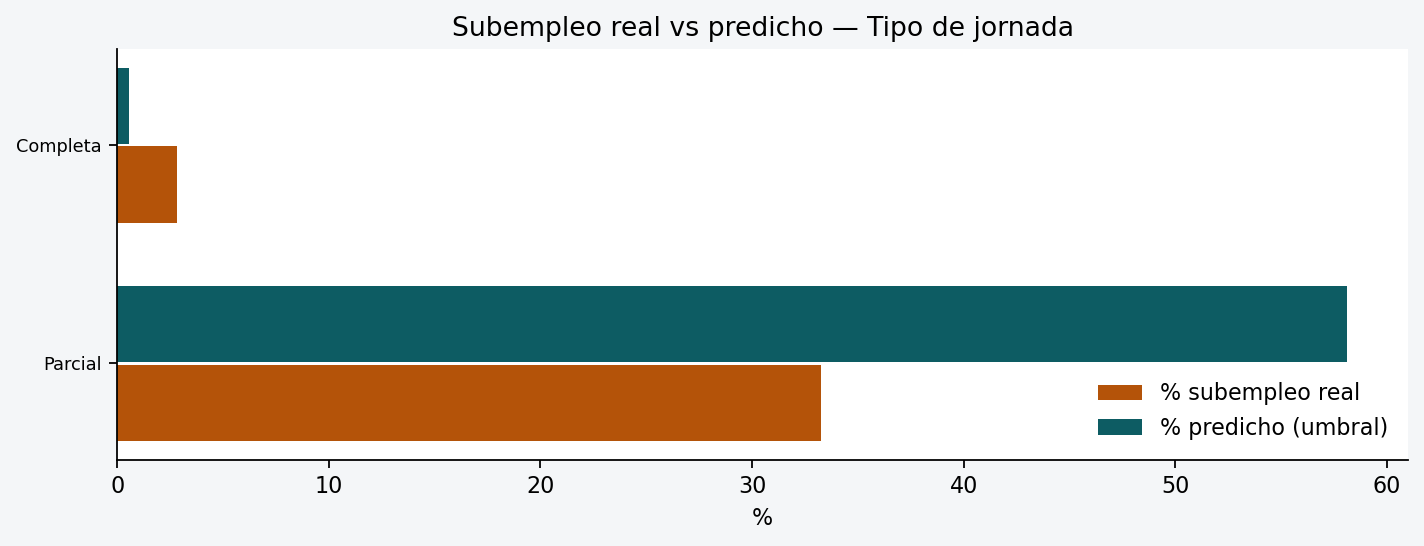

#### `errores_por_ocupacion.png`

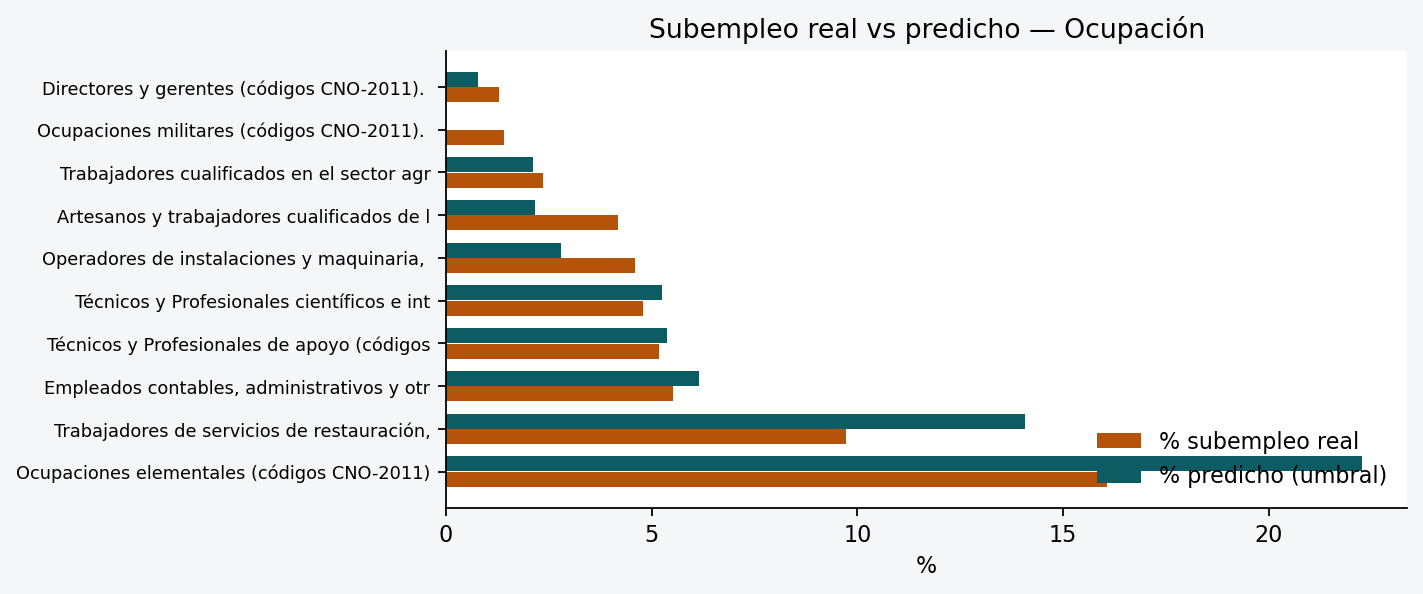

#### `errores_por_sector.png`

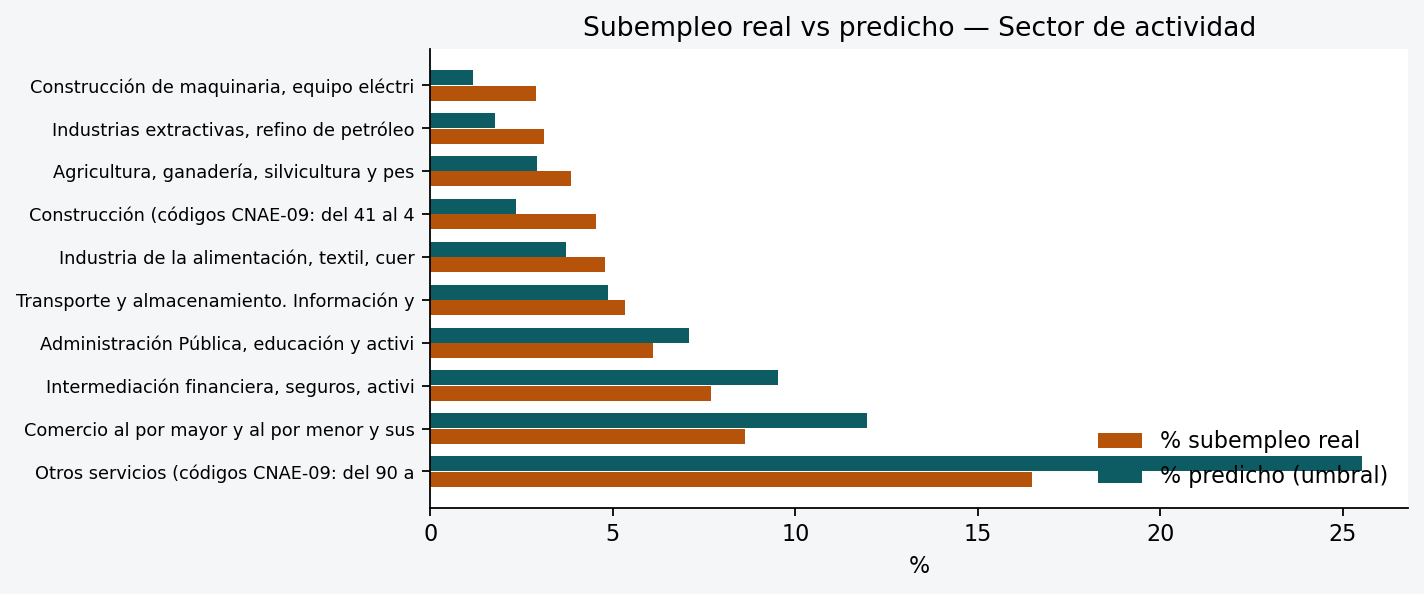

#### `shap_waterfall_fn_subempleo.png`

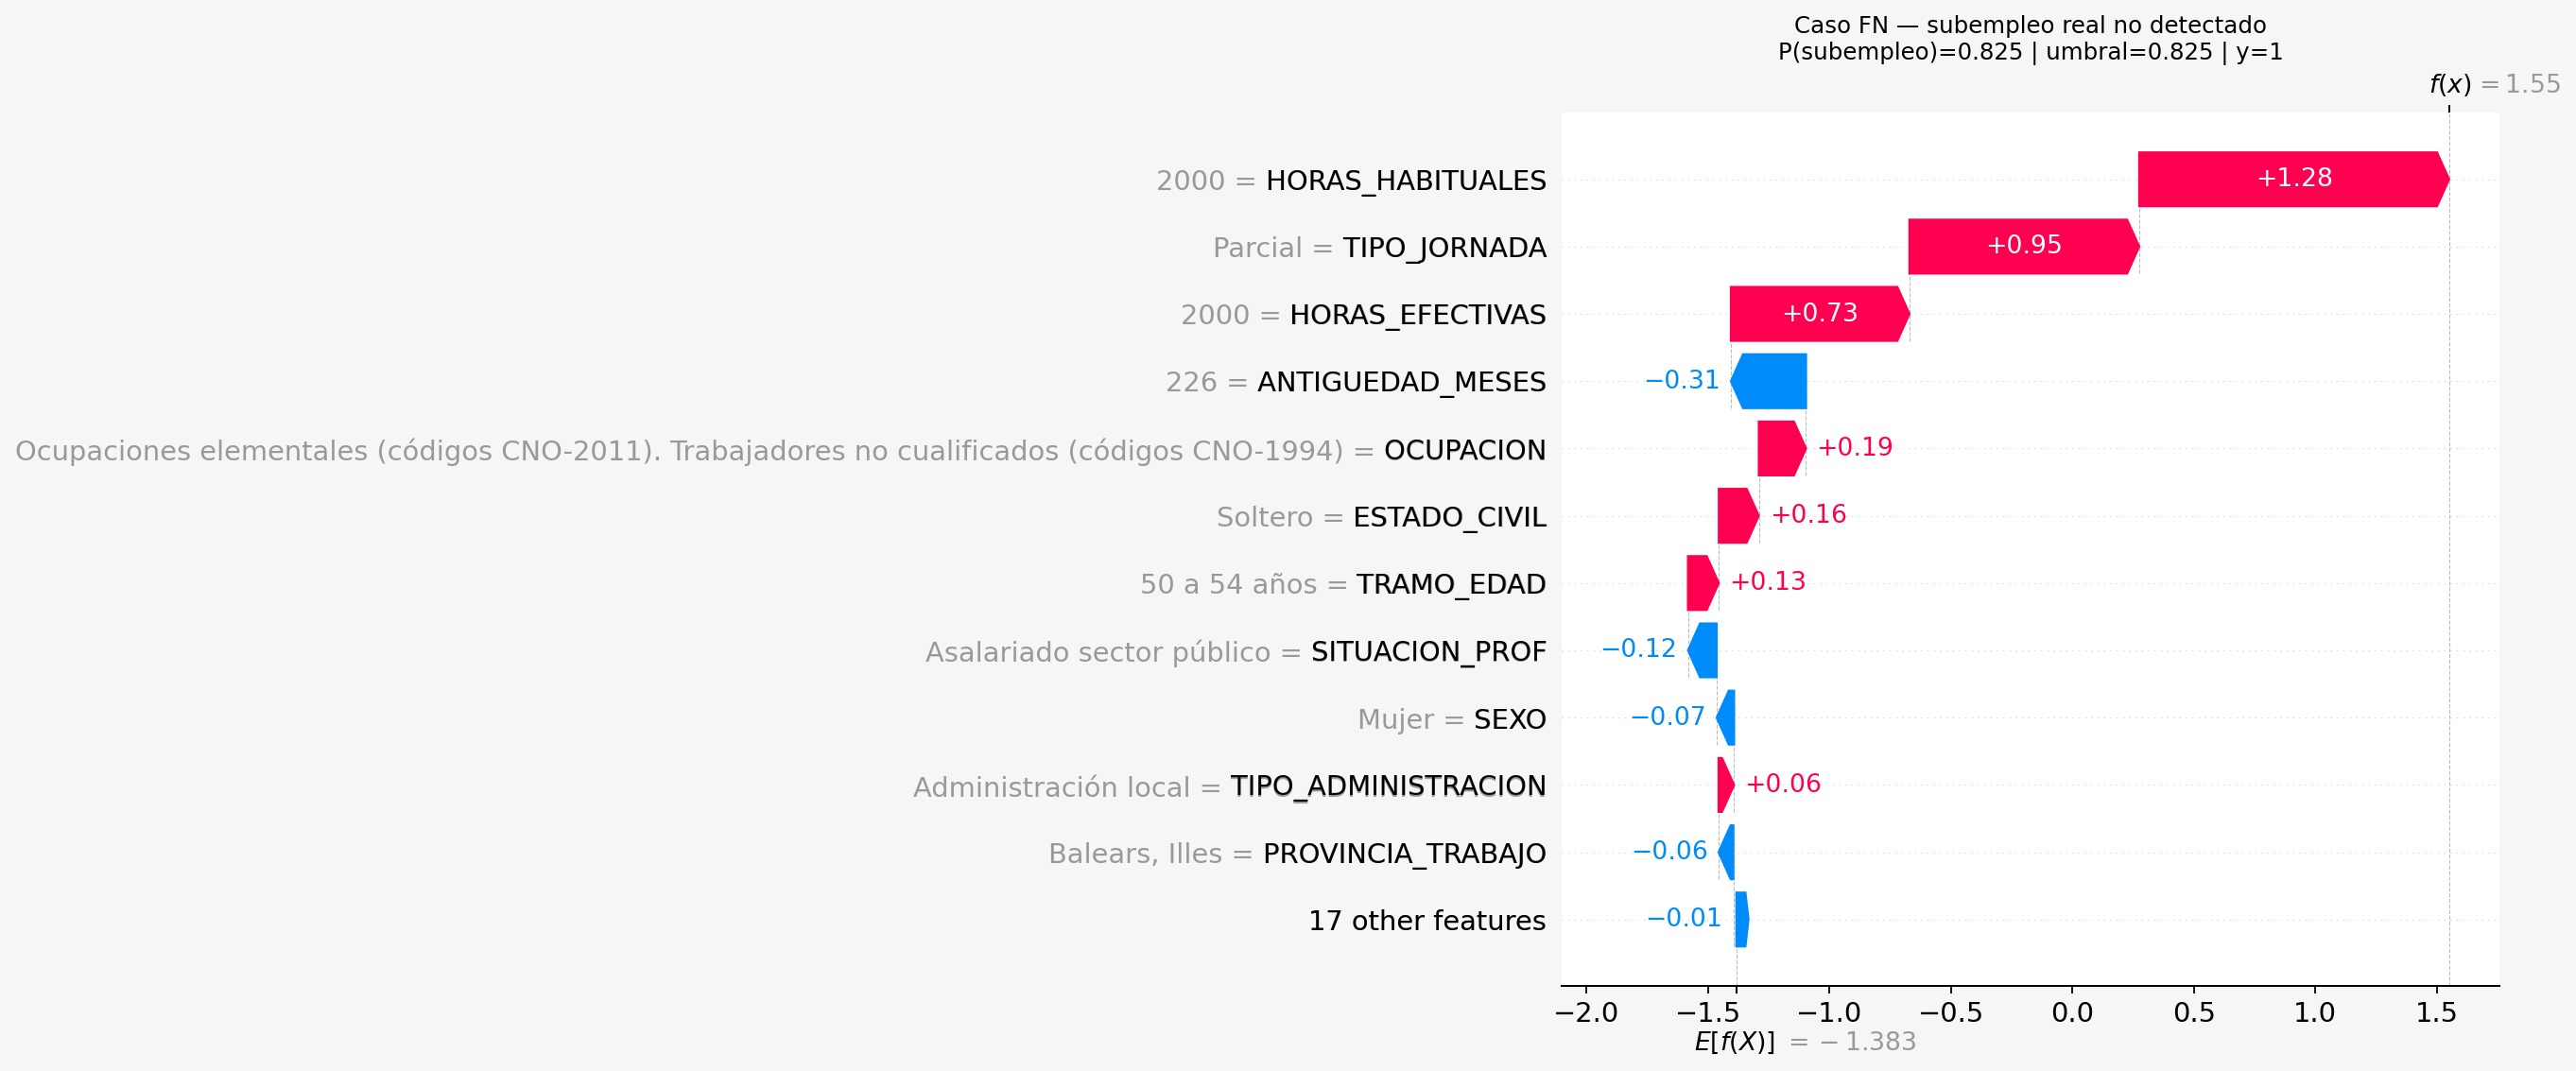

#### `shap_waterfall_tn_no_subempleo.png`

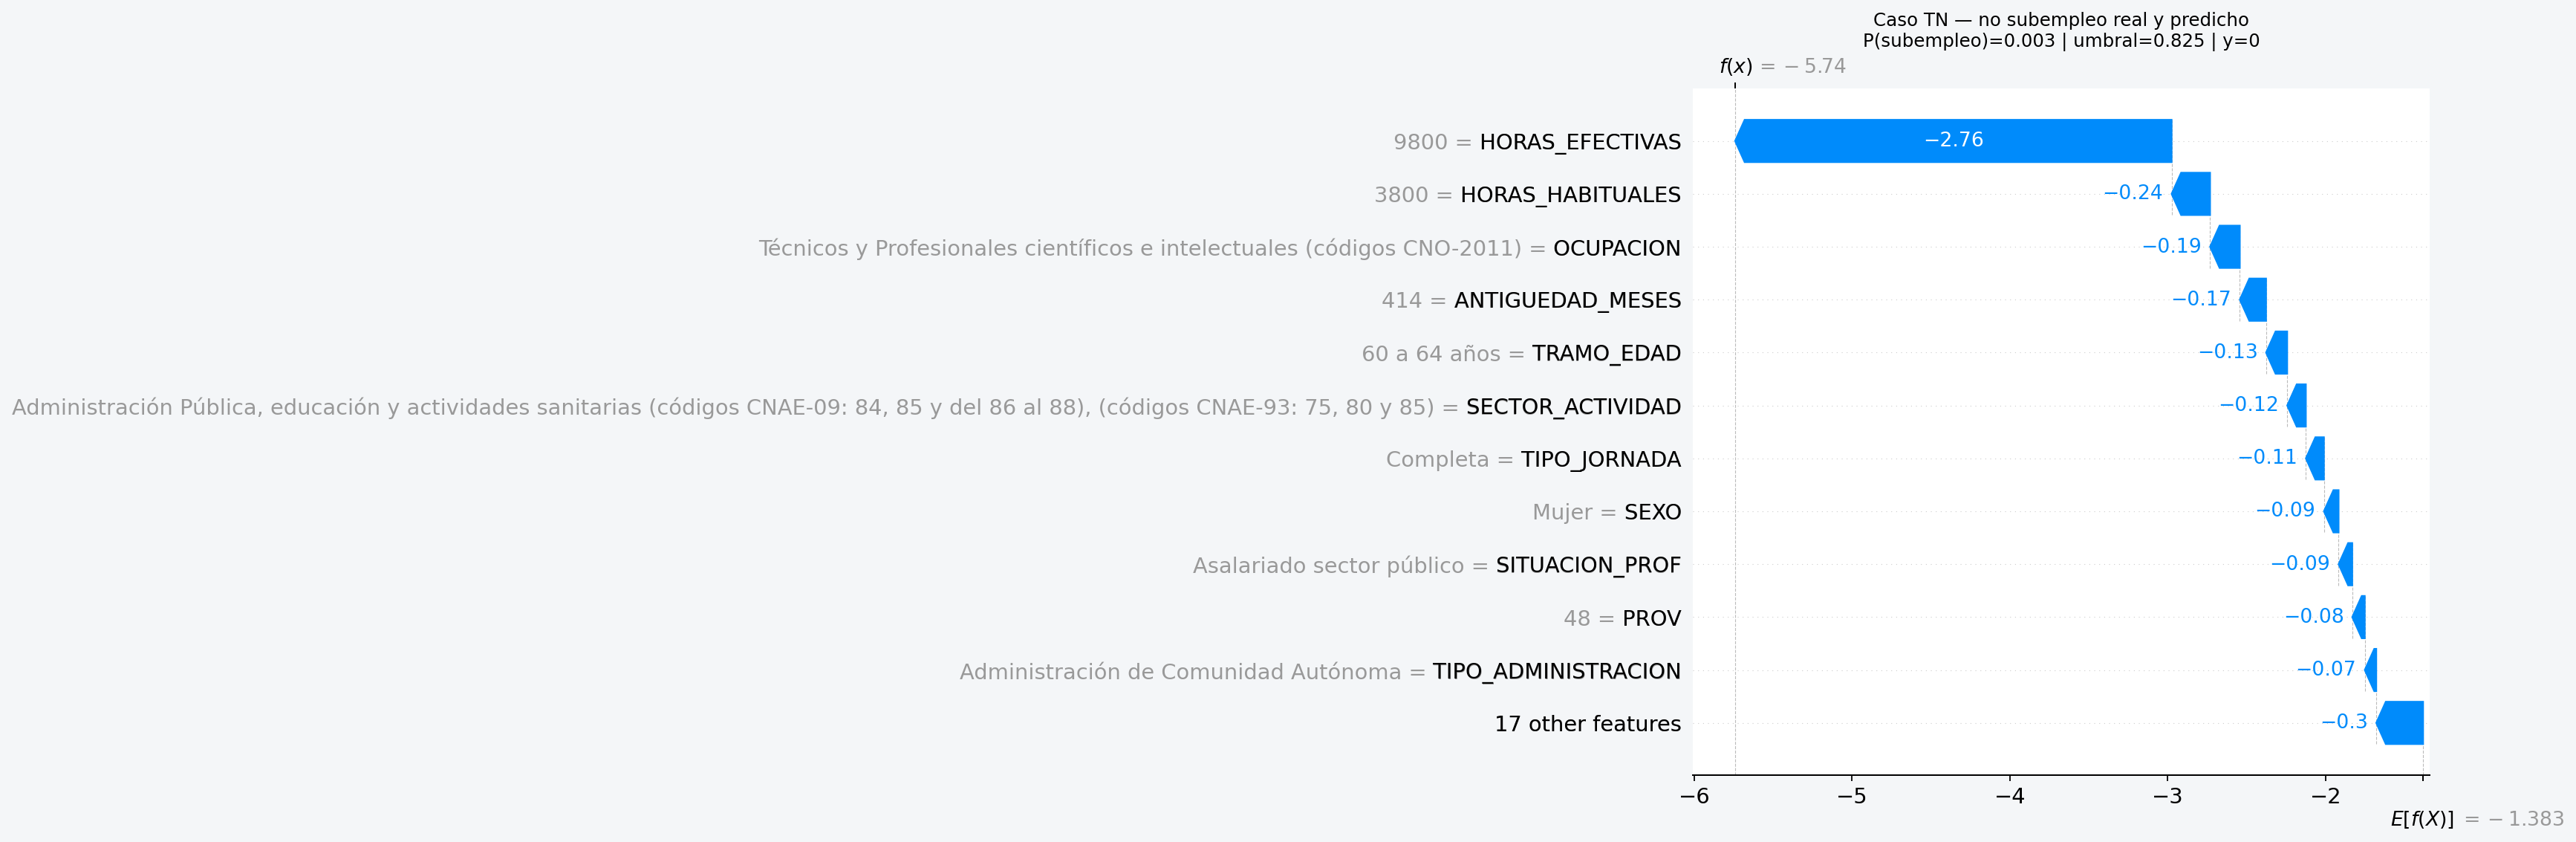

#### `shap_waterfall_tp_subempleo.png`

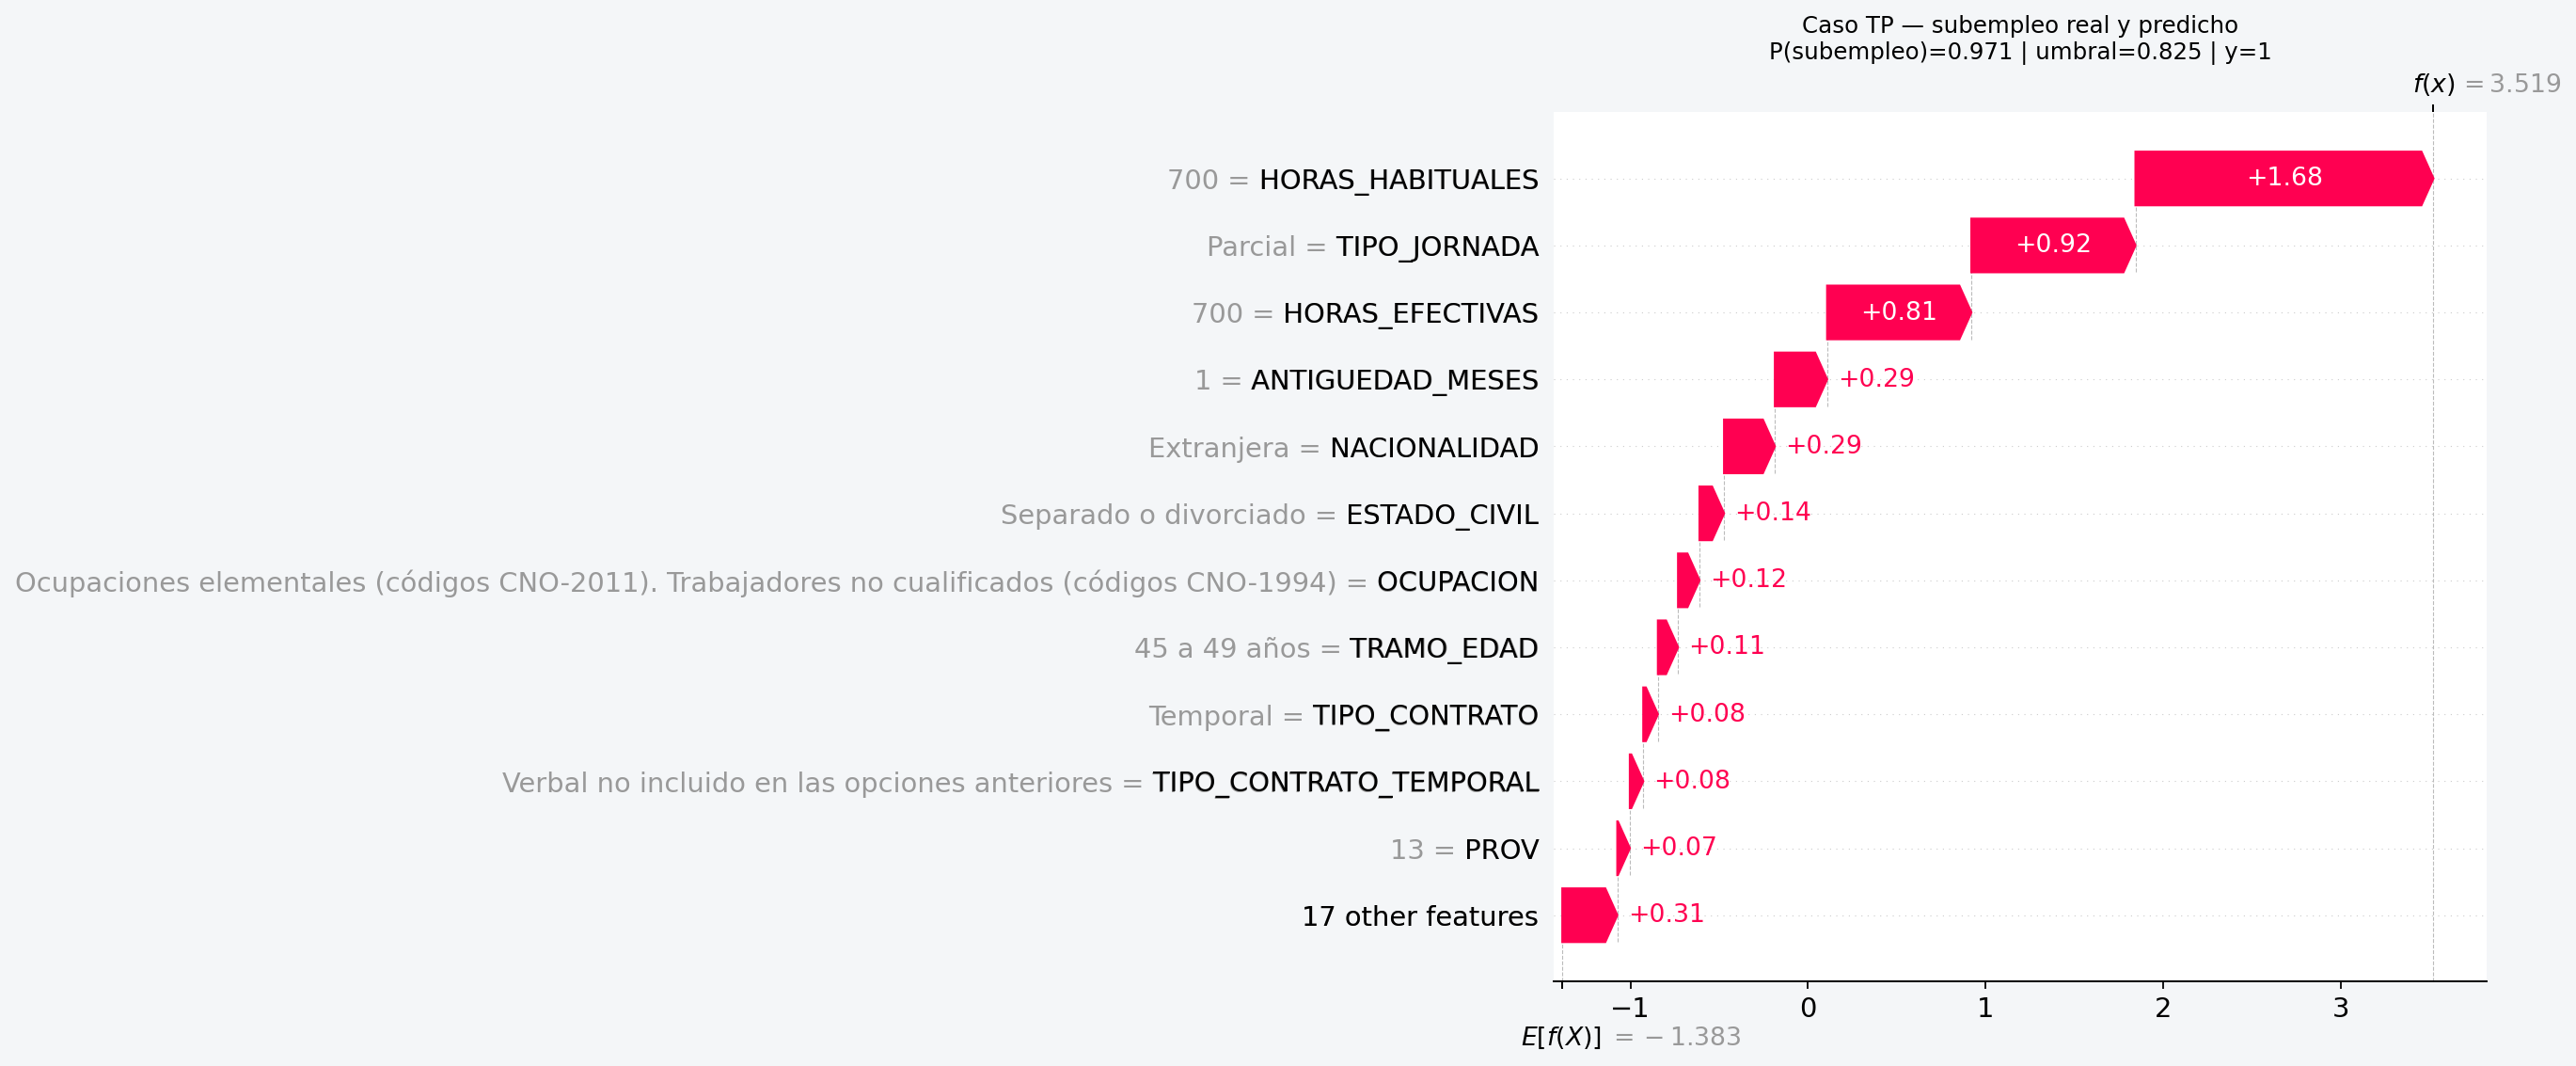

In [3]:
from IPython.display import Image, Markdown, display

dirs = [
    ROOT / "reports/figures/fase2",
    ROOT / "reports/figures/fase2/cierre",
]
for d in dirs:
    display(Markdown(f"### `{d.relative_to(ROOT)}`"))
    for fig in sorted(d.glob("*.png")):
        display(Markdown(f"#### `{fig.name}`"))
        display(Image(data=fig.read_bytes(), width=720))


## 4. Decisiones de la Fase 2

| Decisión | Evidencia |
|---|---|
| Variables laborales aportan | Ablación: PR-AUC demografía << completo |
| Anti-leakage (sin MASHOR/…) | Target AOI=03 oficial; horas como riesgo, no definición |
| Umbral calibrado F1 | Matriz @0.825 vs @0.50 |
| XAI accionable | Waterfalls TP / TN / FN |
| Lectura de calidad del empleo | Errores por jornada, sector, ocupación, CCAA |

Números y figuras de la Fase 2.
